## Open the dataset

In [2]:
import pandas as pd

df_loaded = pd.read_pickle("/scratch/mch/fackerma/orders/Climatology_data/AA_RF_Clim_pred.pkl")
df = df_loaded

In [3]:
counts = df["pred_label"].value_counts()
print(counts)

# Just the 'Yes' count
yes_count = counts["Yes"]
print(f"Number of 'Yes': {yes_count}")

# 'Yes' as percentage
yes_pct = counts["Yes"] / len(df) * 100
print(f"'Yes' percentage: {yes_pct:.1f}%")


pred_label
No     645755
Yes      9482
Name: count, dtype: int64
Number of 'Yes': 9482
'Yes' percentage: 1.4%


In [4]:
# Print all columns
for col in df.columns:
    print(col)

index
traj_ID
yyyymmddHHMM
lon
lat
ell_L
ell_S
ell_or
area
vel_x
vel_y
det
RANKr
CG-
CG+
CGL
%CG+
ET45
Z EchoTop 45
ET15
ET15m
VIL
maxH
maxHm
POH
MESHS
Dvel_x
Dvel_y
VILD
POHm3
POH90
POH75
nrPOH
nrPOH90
nrPOH75
MESHSm3
MESHS90
MESHS75
nrMESHS
nrMESHS90
nrMESHS75
HT0m3
HT090
HT075
D_HT0
dBZmax
dBZm3
dBZ90
dBZ75
nrdBZ90
nrdBZ75
area45
area57
ICL
TotL
RRm3
RR90
RR75
nrRR90
nrRR75
IR108max
IR108med
IR108min
nrMESHSthr20
nrMESHSthr25
nrMESHSthr30
nrMESHSthr35
nrMESHSthr40
nrMESHSthr45
nrMESHSthr50
nrMESHSthr55
nrMESHSthr60
nrPOHthr001
nrPOHthr010
nrPOHthr020
nrPOHthr030
nrPOHthr040
nrPOHthr050
nrPOHthr060
nrPOHthr070
nrPOHthr080
nrPOHthr090
nrPOHthr100
poly_zip
ch_140
Z COM alt
ZH_percent_above_30
Z > 35
Z > 40
Z > 45
ZH_percent_above_50
ZH_percent_above_55
KDP_com_height
KDP > 2
KDP > 1.5
KDP > 1
KDP > 0.5
rad_shear_max
RS > 2.5
RS > 2
RS > 1.5
RS > 1
RS > 0.5
area_p
ZH_45_height
ZH_20_height
ZH_95th_percentile
ZH_95th_percentile_height
ZH_max
ZH_max_height
KDP_95th_percentile
KDP_95th_per

In [5]:
# GPSConverter for coordinate transformation
class GPSConverter(object):
    '''
    GPS Converter class which is able to perform convertions between the 
    CH1903 and WGS84 system.
    '''
    # Convert CH y/x/h to WGS height
    def CHtoWGSheight(self, y, x, h):
        # Axiliary values (% Bern)
        y_aux = (y - 600000) / 1000000
        x_aux = (x - 200000) / 1000000
        h = (h + 49.55) - (12.60 * y_aux) - (22.64 * x_aux)
        return h

    # Convert CH y/x to WGS lat
    def CHtoWGSlat(self, y, x):
        # Axiliary values (% Bern)
        y_aux = (y - 600000) / 1000000
        x_aux = (x - 200000) / 1000000
        lat = (16.9023892 + (3.238272 * x_aux)) + \
                - (0.270978 * pow(y_aux, 2)) + \
                - (0.002528 * pow(x_aux, 2)) + \
                - (0.0447 * pow(y_aux, 2) * x_aux) + \
                - (0.0140 * pow(x_aux, 3))
        # Unit 10000" to 1" and convert seconds to degrees (dec)
        lat = (lat * 100) / 36
        return lat

    # Convert CH y/x to WGS long
    def CHtoWGSlng(self, y, x):
        # Axiliary values (% Bern)
        y_aux = (y - 600000) / 1000000
        x_aux = (x - 200000) / 1000000
        lng = (2.6779094 + (4.728982 * y_aux) + \
                + (0.791484 * y_aux * x_aux) + \
                + (0.1306 * y_aux * pow(x_aux, 2))) + \
                - (0.0436 * pow(y_aux, 3))
        # Unit 10000" to 1" and convert seconds to degrees (dec)
        lng = (lng * 100) / 36
        return lng

    # Convert decimal angle (° dec) to sexagesimal angle (dd.mmss,ss)
    def DecToSexAngle(self, dec):
        degree = int(math.floor(dec))
        minute = int(math.floor((dec - degree) * 60))
        second = (((dec - degree) * 60) - minute) * 60
        return degree + (float(minute) / 100) + (second / 10000)
		
    # Convert sexagesimal angle (dd.mmss,ss) to seconds
    def SexAngleToSeconds(self, dms):
        degree = 0 
        minute = 0 
        second = 0
        degree = math.floor(dms)
        minute = math.floor((dms - degree) * 100)
        second = (((dms - degree) * 100) - minute) * 100
        return second + (minute * 60) + (degree * 3600)

    # Convert sexagesimal angle (dd.mmss) to decimal angle (degrees)
    def SexToDecAngle(self, dms):
        degree = 0
        minute = 0
        second = 0
        degree = math.floor(dms)
        minute = math.floor((dms - degree) * 100)
        second = (((dms - degree) * 100) - minute) * 100
        return degree + (minute / 60) + (second / 3600)
    
    # Convert WGS lat/long (° dec) and height to CH h
    def WGStoCHh(self, lat, lng, h):
        lat = self.DecToSexAngle(lat)
        lng = self.DecToSexAngle(lng)
        lat = self.SexAngleToSeconds(lat)
        lng = self.SexAngleToSeconds(lng)
        # Axiliary values (% Bern)
        lat_aux = (lat - 169028.66) / 10000
        lng_aux = (lng - 26782.5) / 10000
        h = (h - 49.55) + (2.73 * lng_aux) + (6.94 * lat_aux)
        return h

    # Convert WGS lat/long (° dec) to CH x
    def WGStoCHx(self, lat, lng):
        lat = self.DecToSexAngle(lat)
        lng = self.DecToSexAngle(lng)
        lat = self.SexAngleToSeconds(lat)
        lng = self.SexAngleToSeconds(lng)
        # Axiliary values (% Bern)
        lat_aux = (lat - 169028.66) / 10000
        lng_aux = (lng - 26782.5) / 10000
        x = ((200147.07 + (308807.95 * lat_aux) + \
            + (3745.25 * pow(lng_aux, 2)) + \
            + (76.63 * pow(lat_aux,2))) + \
            - (194.56 * pow(lng_aux, 2) * lat_aux)) + \
            + (119.79 * pow(lat_aux, 3))
        return x

	# Convert WGS lat/long (° dec) to CH y
    def WGStoCHy(self, lat, lng):
        lat = self.DecToSexAngle(lat)
        lng = self.DecToSexAngle(lng)
        lat = self.SexAngleToSeconds(lat)
        lng = self.SexAngleToSeconds(lng)
        # Axiliary values (% Bern)
        lat_aux = (lat - 169028.66) / 10000
        lng_aux = (lng - 26782.5) / 10000
        y = (600072.37 + (211455.93 * lng_aux)) + \
            - (10938.51 * lng_aux * lat_aux) + \
            - (0.36 * lng_aux * pow(lat_aux, 2)) + \
            - (44.54 * pow(lng_aux, 3))
        return y

    def LV03toWGS84(self, east, north, height):
        '''
        Convert LV03 to WGS84 Return a array of double that contain lat, long,
        and height
        '''
        d = []
        d.append(self.CHtoWGSlat(east, north))
        d.append(self.CHtoWGSlng(east, north))
        d.append(self.CHtoWGSheight(east, north, height))
        return d
        
    def WGS84toLV03(self, latitude, longitude, ellHeight):
        '''
        Convert WGS84 to LV03 Return an array of double that contaign east,
        north, and height
        '''
        d = []
        d.append(self.WGStoCHy(latitude, longitude))
        d.append(self.WGStoCHx(latitude, longitude))
        d.append(self.WGStoCHh(latitude, longitude, ellHeight))
        return d
        
if __name__ == "__main__":
    ''' Example usage for the GPSConverter class.'''

    converter = GPSConverter()

    # Coordinates
    wgs84 = []
    lv03  = [567719, 155077, 1974]
    #567719/ 155077  Altitude: 1974
    # Convert WGS84 to LV03 coordinates
    wgs84 = converter.LV03toWGS84(lv03[0], lv03[1], lv03[2])

    print("WGS84: ")
    print(wgs84)
    print("LV03: ")
    print(lv03)


# c_transform
def c_transform(lon,lat):
    """
    transforms arrays of lat/lon to chx/chy

    Parameters
    ----------
    lon : float
        longitude.
    lat : float
        latitude.

    Returns
    -------
    chx : float
        chx in m.
    chy : float
        chy in m.

    """
    converter = GPSConverter()
    chx=np.zeros([len(lon)])
    chy=np.zeros([len(lon)])
    for n in range(len(lon)):
        chx[n],chy[n],z=converter.WGS84toLV03(lat[n], lon[n], 0)
    return chx,chy

# transform_c 
def transform_c(chx,chy):
    """
    transforms arrays of chx/chy to lat/lon
    
    Parameters
    -------
    chx : float
        chx in m.
    chy : float
        chy in m.
        
    Returns
    ----------
    lon : float
        longitude.
    lat : float
        latitude.



    """
    converter = GPSConverter()
    lon=np.zeros([len(chx)])
    lat=np.zeros([len(chy)])
    for n in range(len(lon)):
        lat[n], lon[n],z=converter.LV03toWGS84(chx[n],chy[n], 0)
    return lon,lat

WGS84: 
[46.54620053012867, 7.017760746224894, 2024.97379732]
LV03: 
[567719, 155077, 1974]


## Cumulative map

hist max: 39.0 non-zero: 1764


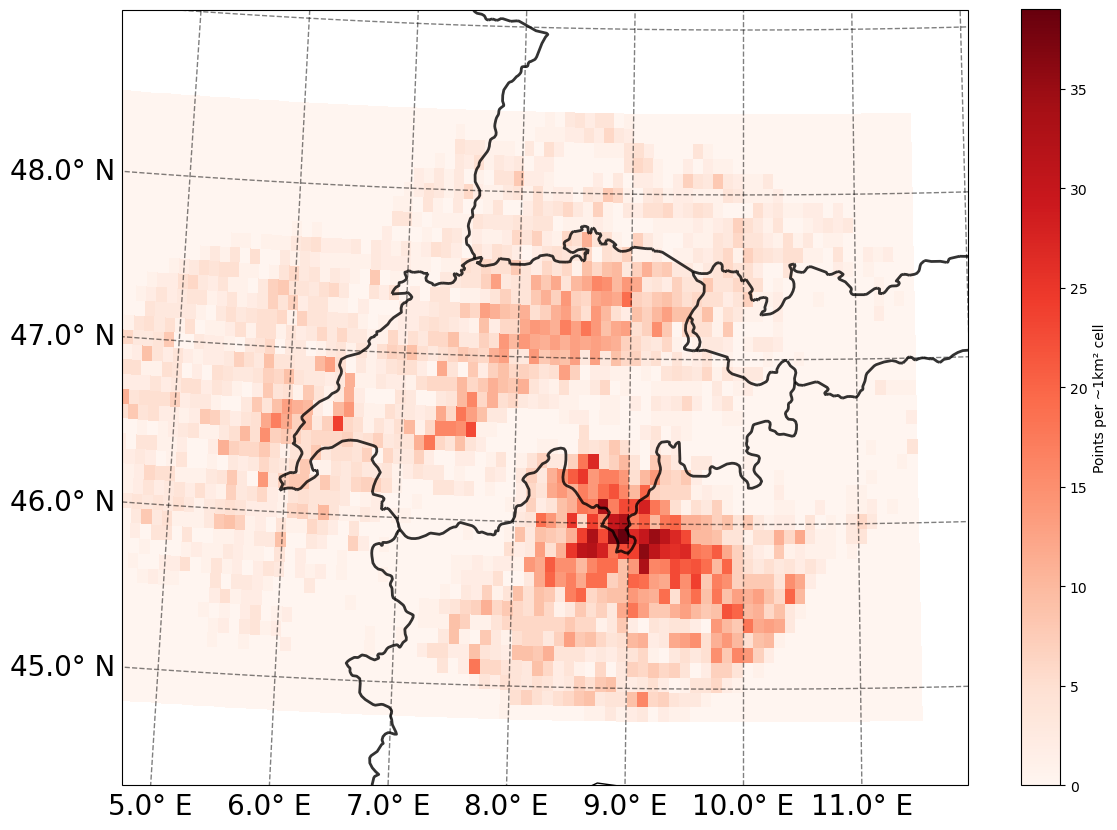

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import cartopy.mpl.ticker as cticker




# 1. Create lon/lat density grid (same as your working PlateCarree version)
df_yes = df[df["pred_label"] == "Yes"].copy()
lon = df_yes["lon"].values
lat = df_yes["lat"].values

# 1km ~ 0.009 degrees, but use finer bins for smooth look
lon_bins = np.arange(lon.min(), lon.max() + 0.01, 0.09)
lat_bins = np.arange(lat.min(), lat.max() + 0.009, 0.09)

hist, lon_edges, lat_edges = np.histogram2d(lon, lat, bins=(lon_bins, lat_bins))
print("hist max:", hist.max(), "non-zero:", np.count_nonzero(hist))

# 2. EPSG:3035 map (less distortion!)
projection = ccrs.epsg(3035)
extent = [4.75, 11.9, 44.4, 49]  # Your Switzerland extent

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': projection})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# 3. Plot lon/lat grid on EPSG:3035 map
im = ax.pcolormesh(lon_edges, lat_edges, hist.T,
                   cmap="Reds",  # red=higher
                   transform=ccrs.PlateCarree(),  # <- DATA is lon/lat!
                   shading='flat')

# Your styling
ax.add_feature(cfeature.BORDERS, edgecolor='black', alpha=0.8, linewidth=2)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, 
                  color='black', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 20, 'color': 'black'}
gl.ylabel_style = {'size': 20, 'color': 'black'}
gl.xformatter = cticker.LongitudeFormatter(number_format='.1f', degree_symbol='° ')
gl.yformatter = cticker.LatitudeFormatter(number_format='.1f', degree_symbol='° ')

#ax.set_title(f"RF 'Yes' density: EPSG:3035 map (n={len(df_yes)})", fontsize=24, pad=20)
plt.colorbar(im, ax=ax, label="Points per ~1km² cell", shrink=0.8)
plt.tight_layout()
plt.show()



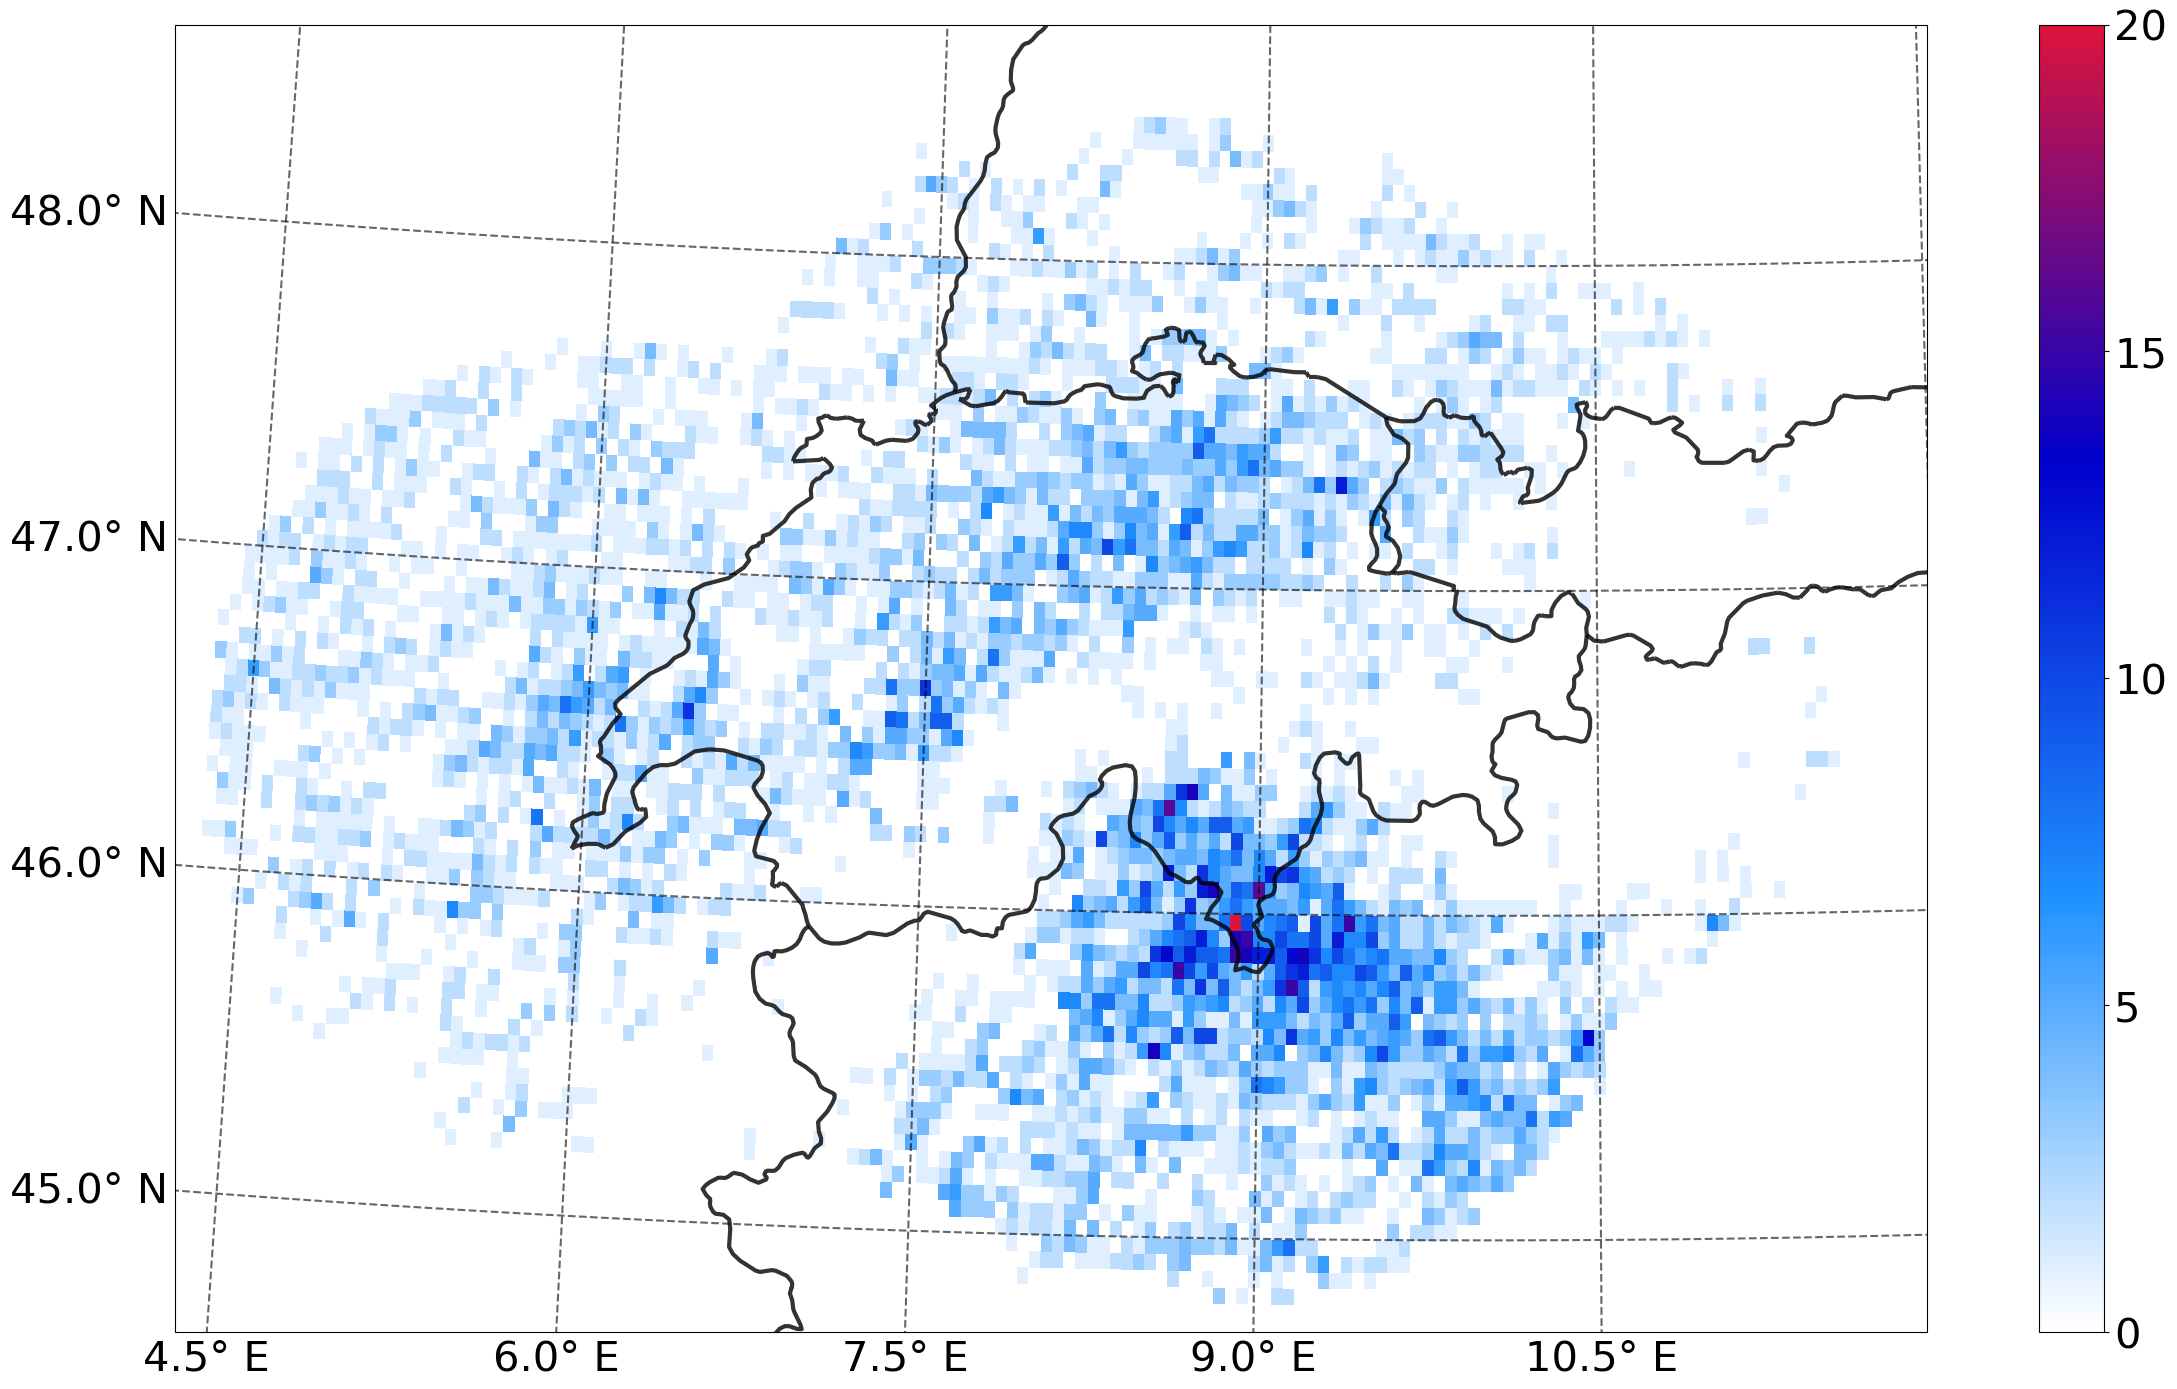

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import cartopy.mpl.ticker as cticker
from matplotlib.colors import BoundaryNorm, ListedColormap, LinearSegmentedColormap


# 1. Smooth GRADIENT colormap (white→blue→yellow→red)
colors = ["white", "dodgerblue", "mediumblue", "crimson"]
cmap = LinearSegmentedColormap.from_list("gradient", colors, N=256)

# 2. Your discrete levels
levels = [0, 5, 10, 15, 20, 25, 30, 35]

# 3. BoundaryNorm for discrete steps WITHIN the smooth gradient
norm = BoundaryNorm(levels, cmap.N, clip=True)

# 1. Density grid (lon/lat bins ~1km)
df_yes = df[df["pred_label"] == "Yes"].copy()
lon = df_yes["lon"].values
lat = df_yes["lat"].values

lon_bins = np.arange(lon.min(), lon.max() + 0.01, 0.05)
lat_bins = np.arange(lat.min(), lat.max() + 0.009, 0.05)

hist, lon_edges, lat_edges = np.histogram2d(lon, lat, bins=(lon_bins, lat_bins))

# 3. EPSG:3035 plot (figsize 24x10)
projection = ccrs.epsg(3035)
extent = [4.35, 11.9, 44.7, 48.6]

fig, ax = plt.subplots(figsize=(24, 14), subplot_kw={'projection': projection})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Plot density
im = ax.pcolormesh(lon_edges, lat_edges, hist.T,
                   cmap=cmap,
                   #norm=norm,
                   transform=ccrs.PlateCarree(),
                   shading='flat')

# Features
ax.add_feature(cfeature.BORDERS, edgecolor='black', alpha=0.8, linewidth=3)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))

# Gridlines + labels size 30
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1.5, 
                  color='black', alpha=0.6, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 30, 'color': 'black'}
gl.ylabel_style = {'size': 30, 'color': 'black'}
gl.xformatter = cticker.LongitudeFormatter(number_format='.1f', degree_symbol='° ')
gl.yformatter = cticker.LatitudeFormatter(number_format='.1f', degree_symbol='° ')

# Colorbar with size 30 labels

cbar = plt.colorbar(im, ax=ax, shrink=1, pad=0.05, ticks=levels)
cbar.ax.set_yticklabels([f'{int(l)}' for l in levels])
cbar.ax.tick_params(labelsize=30)
#cbar.set_label("Points per ~1km² cell", size=30, weight='bold', labelpad=20)

plt.tight_layout()

#plt.savefig('/users/fackerma/newproject1/figures/Paper/AA_Clim_2.pdf', bbox_inches='tight')
